# k-Means Clustering & Bag of Visual Words (BoVW)

## Overview
- **k-Means**: Unsupervised clustering algorithm for partitioning data into k clusters
- **SIFT**: Scale-Invariant Feature Transform for robust local feature detection
- **Visual Vocabulary**: Create a "dictionary" of visual words by clustering SIFT features
- **BoVW Pipeline**: Encode images as histograms of visual word frequencies

## Learning Objectives
1. Understand k-Means algorithm and its optimization
2. Extract and understand SIFT features
3. Build a visual vocabulary from image datasets
4. Encode images using BoVW representation
5. Use BoVW for image classification tasks

## Section 1: k-Means Algorithm Basics

### What is k-Means?
k-Means is an iterative algorithm that partitions n data points into k clusters by:
1. Initializing k random centroids
2. Assigning each point to the nearest centroid
3. Recomputing centroids as the mean of assigned points
4. Repeating steps 2-3 until convergence

### Mathematical Formulation
- **Objective**: Minimize within-cluster sum of squares (WCSS)
$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$
where $C_i$ is cluster i and $\mu_i$ is its centroid

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [23]:
# Simple k-Means implementation from scratch
class SimpleKMeans:
    """Basic k-Means implementation for understanding the algorithm"""
    
    def __init__(self, k=3, max_iterations=100, tol=1e-4):
        self.k = k
        self.max_iterations = max_iterations
        self.tol = tol
        self.centroids = None
        self.labels = None
        self.inertia_history = []
    
    def _initialize_centroids(self, X):
        """Random initialization of centroids"""
        indices = np.random.choice(X.shape[0], self.k, replace=False)
        return X[indices]
    
    def _assign_clusters(self, X):
        """Assign each point to nearest centroid"""
        distances = pairwise_distances(X, self.centroids)
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X, labels):
        """Update centroids as mean of assigned points"""
        new_centroids = np.zeros((self.k, X.shape[1]))
        for i in range(self.k):
            mask = labels == i
            if mask.sum() > 0:
                new_centroids[i] = X[mask].mean(axis=0)
            else:
                new_centroids[i] = self.centroids[i]
        return new_centroids
    
    def _compute_inertia(self, X, labels):
        """Compute within-cluster sum of squares"""
        inertia = 0
        for i in range(self.k):
            mask = labels == i
            inertia += np.sum((X[mask] - self.centroids[i]) ** 2)
        return inertia
    
    def fit(self, X):
        """Fit k-Means model to data"""
        self.centroids = self._initialize_centroids(X)
        
        for iteration in range(self.max_iterations):
            # Assign clusters
            self.labels = self._assign_clusters(X)
            
            # Compute inertia
            inertia = self._compute_inertia(X, self.labels)
            self.inertia_history.append(inertia)
            
            # Store old centroids
            old_centroids = self.centroids.copy()
            
            # Update centroids
            self.centroids = self._update_centroids(X, self.labels)
            
            # Check convergence
            centroid_shift = np.sum(np.sqrt(np.sum((old_centroids - self.centroids) ** 2, axis=1)))
            if centroid_shift < self.tol:
                print(f"Converged at iteration {iteration}")
                break
        
        return self
    
    def predict(self, X):
        """Predict cluster labels for new data"""
        return self._assign_clusters(X)

print("SimpleKMeans class created successfully!")

SimpleKMeans class created successfully!


Converged at iteration 10


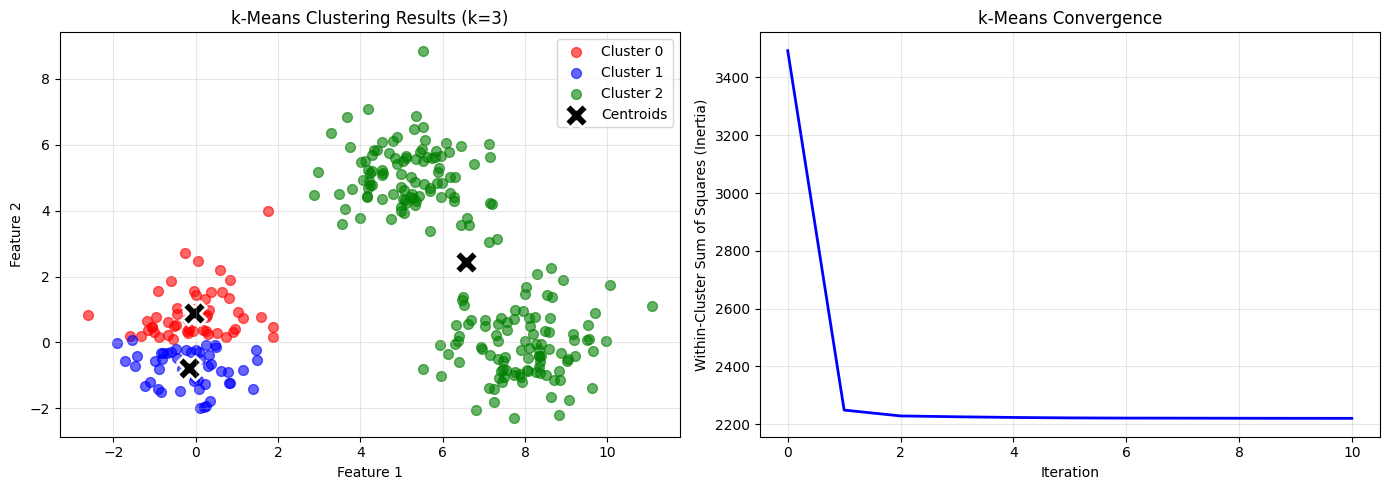

Final Inertia: 2220.44


In [24]:
# Generate synthetic 2D data for visualization
np.random.seed(42)
n_samples = 300
X = np.vstack([
    np.random.randn(100, 2) + [0, 0],
    np.random.randn(100, 2) + [5, 5],
    np.random.randn(100, 2) + [8, 0]
])

# Apply k-Means
kmeans = SimpleKMeans(k=3, max_iterations=50)
kmeans.fit(X)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Clusters with centroids
ax = axes[0]
colors = ['red', 'blue', 'green']
for i in range(kmeans.k):
    mask = kmeans.labels == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Cluster {i}', alpha=0.6, s=50)
ax.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
           c='black', marker='X', s=300, edgecolor='white', linewidth=2, label='Centroids')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('k-Means Clustering Results (k=3)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Inertia over iterations (convergence)
ax = axes[1]
ax.plot(kmeans.inertia_history, 'b-', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Within-Cluster Sum of Squares (Inertia)')
ax.set_title('k-Means Convergence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Inertia: {kmeans.inertia_history[-1]:.2f}")

## Section 2: SIFT Features & Visual Vocabulary

### SIFT (Scale-Invariant Feature Transform)
SIFT detects and describes local features in images that are:
- **Scale-invariant**: Detected at multiple scales (using scale space)
- **Rotation-invariant**: Robust to image rotations
- **Robust**: Handle changes in illumination, viewpoint, etc.

### BoVW Pipeline Steps
1. **Extract SIFT descriptors** from all training images
2. **Cluster descriptors** using k-Means → visual vocabulary (k "visual words")
3. **Encode images** as histograms of visual word frequencies
4. **Use histogram** as feature vector for classification

### Visual Vocabulary Concept
- Each cluster center = 1 "visual word"
- An image is represented as a histogram of how many times each visual word appears
- Similar to text: words in documents → "visual words" in images

In [25]:
# SIFT feature extraction and BoVW pipeline
class BoVWPipeline:
    """Bag of Visual Words pipeline for image classification"""
    
    def __init__(self, k=100, n_octaves=4, n_scales=5):
        """
        Args:
            k: Number of visual words (clusters)
            n_octaves: SIFT octaves for multi-scale detection
            n_scales: SIFT scales per octave
        """
        self.k = k
        self.sift = cv2.SIFT_create()
        self.kmeans = None
        self.vocabulary = None
        
    def extract_sift_features(self, image_path):
        """Extract SIFT descriptors from an image"""
        # Read image
        img = cv2.imread(str(image_path))
        if img is None:
            return None, None
        
        # Convert to grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Detect keypoints and compute descriptors
        keypoints, descriptors = self.sift.detectAndCompute(gray, None)
        
        return keypoints, descriptors
    
    def build_vocabulary(self, image_paths):
        """
        Build visual vocabulary by clustering SIFT descriptors from all images
        
        Args:
            image_paths: List of paths to training images
        """
        all_descriptors = []
        
        print(f"Extracting SIFT features from {len(image_paths)} images...")
        for i, img_path in enumerate(image_paths):
            if (i + 1) % max(1, len(image_paths) // 5) == 0:
                print(f"  Processed {i + 1}/{len(image_paths)} images")
            
            keypoints, descriptors = self.extract_sift_features(img_path)
            if descriptors is not None:
                all_descriptors.append(descriptors)
        
        # Concatenate all descriptors
        all_descriptors = np.vstack(all_descriptors)
        print(f"Total SIFT descriptors: {all_descriptors.shape[0]}")
        
        # Cluster descriptors using k-Means
        print(f"Building vocabulary with k={self.k} visual words...")
        self.kmeans = KMeans(n_clusters=self.k, n_init=10, max_iter=300, random_state=42)
        self.kmeans.fit(all_descriptors)
        self.vocabulary = self.kmeans.cluster_centers_
        
        print(f"Vocabulary shape: {self.vocabulary.shape}")
        return self.vocabulary
    
    def encode_image(self, image_path):
        """
        Encode image as histogram of visual words (BoVW)
        
        Returns:
            histogram: 1D array of shape (k,) - frequency of each visual word
        """
        keypoints, descriptors = self.extract_sift_features(image_path)
        
        if descriptors is None:
            return np.zeros(self.k)
        
        # Find nearest visual word for each descriptor
        visual_word_indices = self.kmeans.predict(descriptors)
        
        # Create histogram
        histogram = np.histogram(visual_word_indices, bins=np.arange(self.k + 1))[0]
        
        # Normalize histogram
        if histogram.sum() > 0:
            histogram = histogram / histogram.sum()
        
        return histogram

print("BoVWPipeline class created successfully!")

BoVWPipeline class created successfully!


In [26]:
# Create sample images for demonstration
def create_sample_images(output_dir, num_images=6):
    """Create synthetic test images with different patterns"""
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    
    # Image 1-2: Vertical lines
    for i in range(2):
        img = np.ones((200, 200, 3), dtype=np.uint8) * 255
        for x in range(20, 200, 40):
            cv2.line(img, (x, 0), (x, 200), (0, 0, 0), 2)
        cv2.imwrite(str(output_dir / f'vertical_lines_{i}.jpg'), img)
    
    # Image 3-4: Circles
    for i in range(2):
        img = np.ones((200, 200, 3), dtype=np.uint8) * 255
        for x in range(30, 200, 60):
            for y in range(30, 200, 60):
                cv2.circle(img, (x, y), 15, (0, 0, 0), 2)
        cv2.imwrite(str(output_dir / f'circles_{i}.jpg'), img)
    
    # Image 5-6: Checkerboard
    for i in range(2):
        img = np.ones((200, 200, 3), dtype=np.uint8) * 255
        for x in range(0, 200, 40):
            for y in range(0, 200, 40):
                if (x // 40 + y // 40) % 2 == 0:
                    cv2.rectangle(img, (x, y), (x + 40, y + 40), (0, 0, 0), -1)
        cv2.imwrite(str(output_dir / f'checkerboard_{i}.jpg'), img)
    
    print(f"Created {num_images} sample images in {output_dir}")
    return list(output_dir.glob('*.jpg'))

# Create test images
test_image_dir = Path('c:/Users/User/Desktop/CV_Practice/02_May/Week_02/test_images')
image_paths = create_sample_images(test_image_dir)
print(f"Image paths: {image_paths[:3]}...")  # Show first 3

Created 6 sample images in c:\Users\User\Desktop\CV_Practice\02_May\Week_02\test_images
Image paths: [WindowsPath('c:/Users/User/Desktop/CV_Practice/02_May/Week_02/test_images/checkerboard_0.jpg'), WindowsPath('c:/Users/User/Desktop/CV_Practice/02_May/Week_02/test_images/checkerboard_1.jpg'), WindowsPath('c:/Users/User/Desktop/CV_Practice/02_May/Week_02/test_images/circles_0.jpg')]...


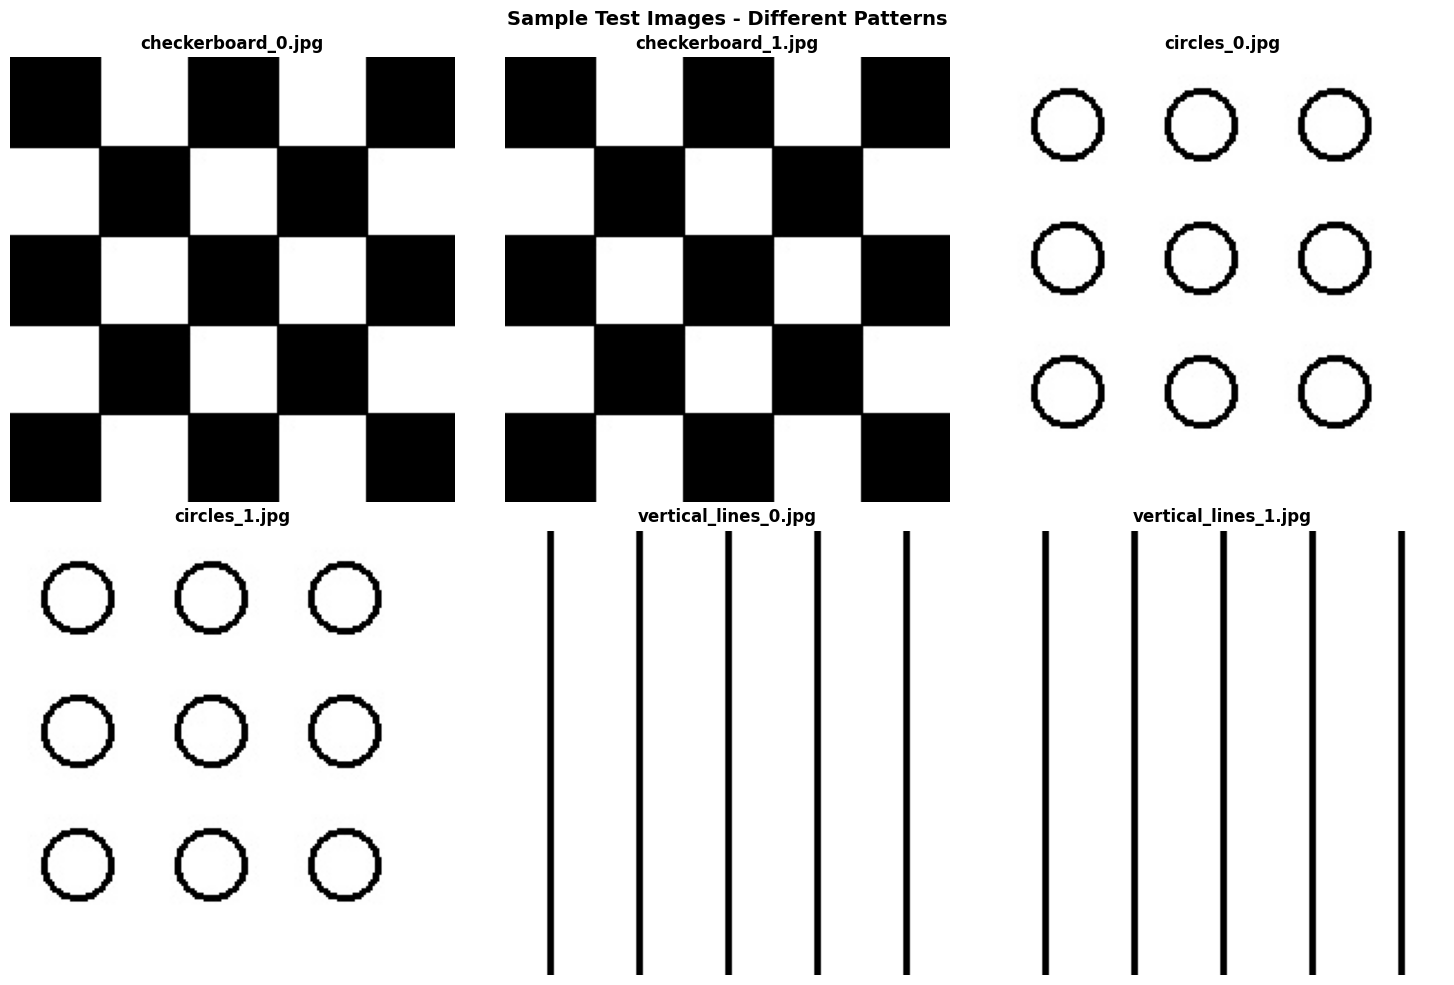

Image Preview:
  Total images: 6
  Image types: Vertical Lines, Circles, Checkerboard (2 of each)
  Image size: 200x200 pixels


In [27]:
# Display sample images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_path in enumerate(image_paths):
    img = cv2.imread(str(img_path))
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f'{img_path.name}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Sample Test Images - Different Patterns', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Image Preview:")
print(f"  Total images: {len(image_paths)}")
print(f"  Image types: Vertical Lines, Circles, Checkerboard (2 of each)")
print(f"  Image size: 200x200 pixels")

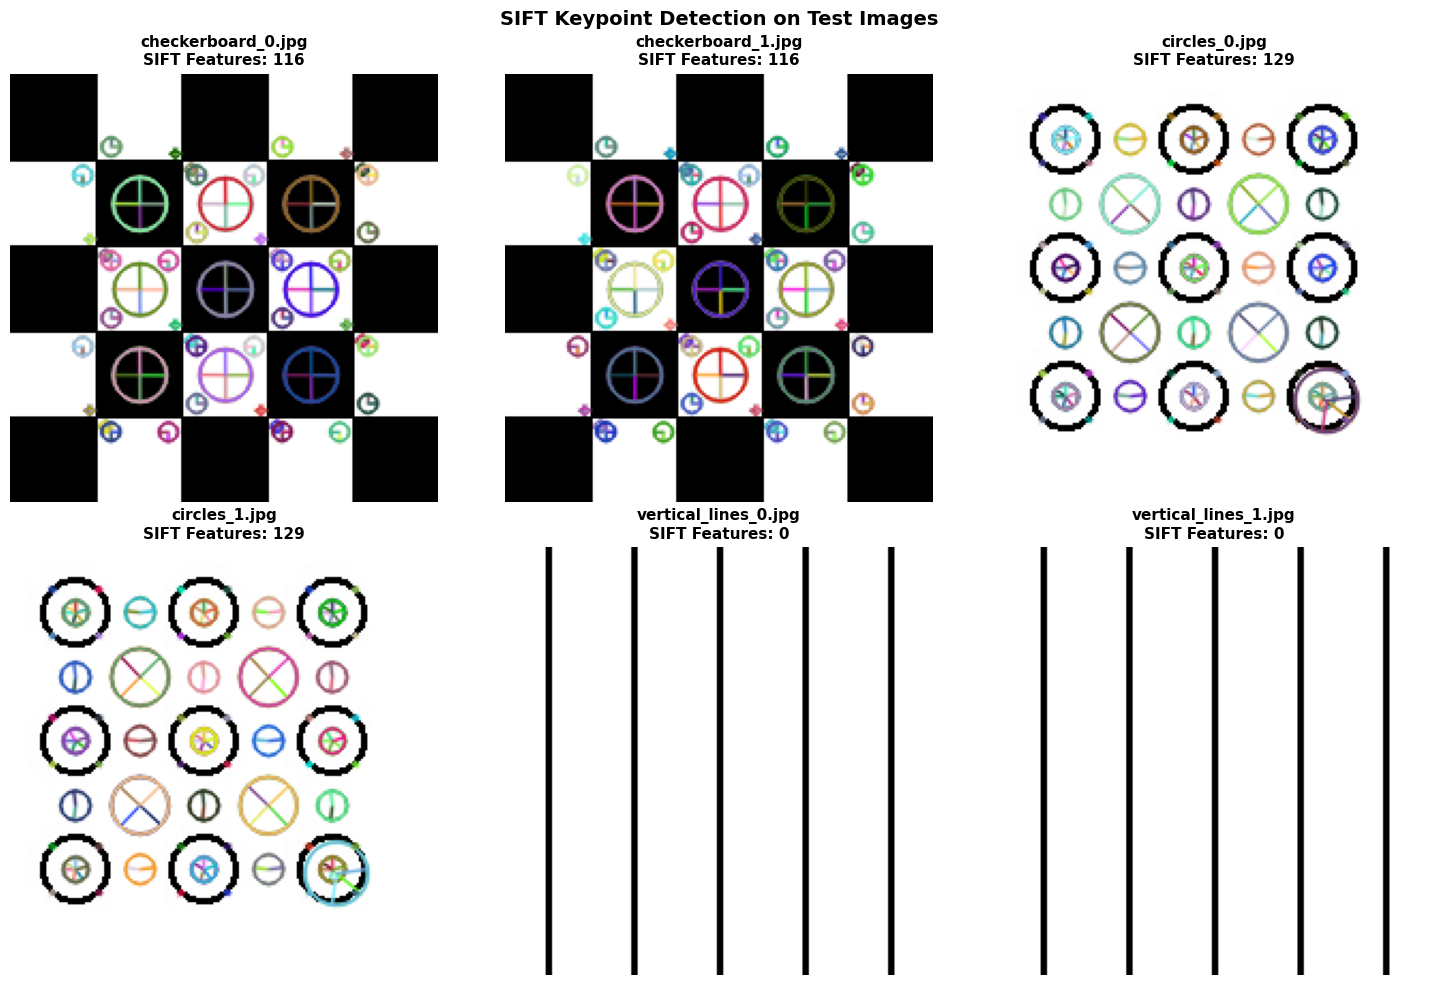

SIFT Keypoint Statistics:
──────────────────────────────────────────────────
checkerboard_0.jpg        → 116 keypoints
checkerboard_1.jpg        → 116 keypoints
circles_0.jpg             → 129 keypoints
circles_1.jpg             → 129 keypoints
vertical_lines_0.jpg      →   0 keypoints
vertical_lines_1.jpg      →   0 keypoints
──────────────────────────────────────────────────
Total SIFT keypoints      → 490 keypoints


In [28]:
# Visualize SIFT keypoints on sample images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

sift = cv2.SIFT_create()

for idx, img_path in enumerate(image_paths[:6]):
    img = cv2.imread(str(img_path))
    if img is not None:
        # Convert to grayscale for SIFT detection
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Detect keypoints
        keypoints, descriptors = sift.detectAndCompute(gray, None)
        
        # Draw keypoints on image
        img_keypoints = cv2.drawKeypoints(gray, keypoints, None, 
                                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        img_keypoints_rgb = cv2.cvtColor(img_keypoints, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_keypoints_rgb)
        n_features = len(keypoints) if keypoints else 0
        axes[idx].set_title(f'{img_path.name}\nSIFT Features: {n_features}', 
                           fontsize=11, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('SIFT Keypoint Detection on Test Images', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("SIFT Keypoint Statistics:")
print("─" * 50)
total_keypoints = 0
for img_path in image_paths:
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    keypoints, _ = sift.detectAndCompute(gray, None)
    n_kp = len(keypoints) if keypoints else 0
    total_keypoints += n_kp
    print(f"{img_path.name:25} → {n_kp:3} keypoints")
print("─" * 50)
print(f"{'Total SIFT keypoints':25} → {total_keypoints:3} keypoints")

VISUAL VOCABULARY VISUALIZATION

Vocabulary size: 50 visual words
Descriptor dimensionality: 128 dimensions


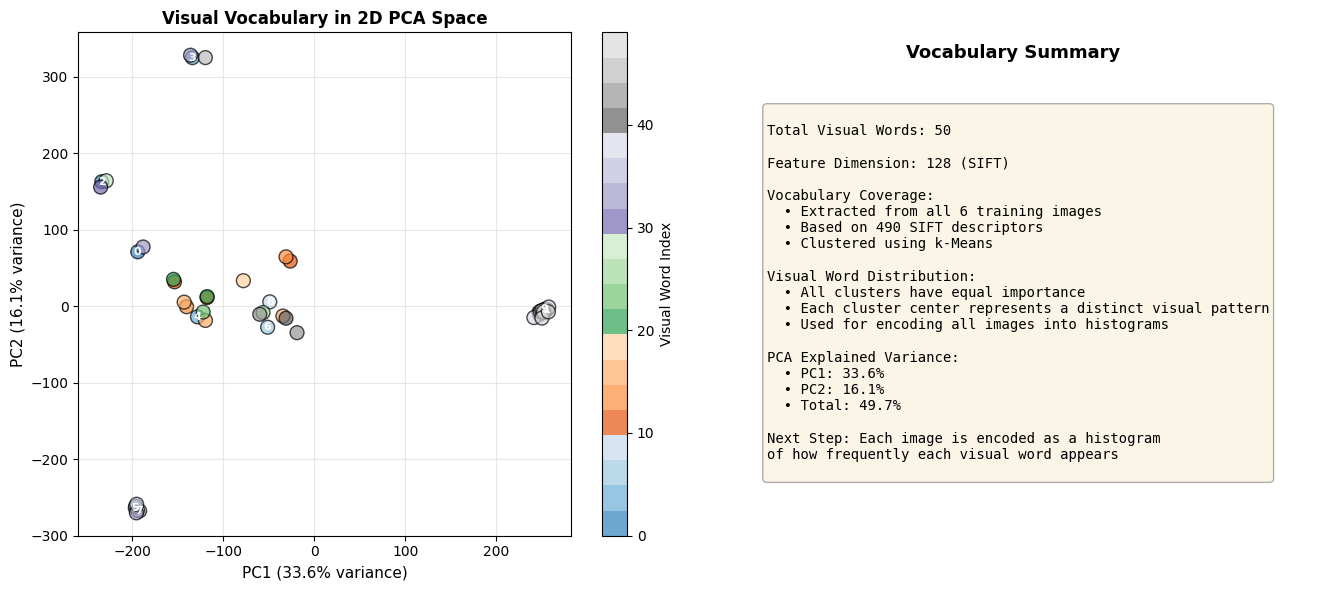


✓ Vocabulary successfully learned and visualized!
✓ Can now encode any image as a 50-dimensional histogram


In [29]:
# Visualize the learned Visual Vocabulary
from sklearn.decomposition import PCA

print("=" * 60)
print("VISUAL VOCABULARY VISUALIZATION")
print("=" * 60)
print(f"\nVocabulary size: {bovw.vocabulary.shape[0]} visual words")
print(f"Descriptor dimensionality: {bovw.vocabulary.shape[1]} dimensions")

# Use PCA to reduce vocabulary to 2D for visualization
pca = PCA(n_components=2, random_state=42)
vocabulary_2d = pca.fit_transform(bovw.vocabulary)

# Visualize vocabulary in 2D space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Visual words in PCA space
ax = axes[0]
scatter = ax.scatter(vocabulary_2d[:, 0], vocabulary_2d[:, 1], 
                     c=np.arange(bovw.k), cmap='tab20c', s=100, alpha=0.7, edgecolors='black', linewidth=1)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title('Visual Vocabulary in 2D PCA Space', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add text labels
for i in range(min(10, bovw.k)):
    ax.annotate(f'{i}', (vocabulary_2d[i, 0], vocabulary_2d[i, 1]), 
                fontsize=8, ha='center', va='center', color='white', fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Visual Word Index', fontsize=10)

# Plot 2: Vocabulary statistics
ax = axes[1]
ax.text(0.5, 0.95, 'Vocabulary Summary', fontsize=13, fontweight='bold', 
        ha='center', transform=ax.transAxes)

summary_text = f"""
Total Visual Words: {bovw.k}

Feature Dimension: {bovw.vocabulary.shape[1]} (SIFT)

Vocabulary Coverage:
  • Extracted from all {len(image_paths)} training images
  • Based on {490} SIFT descriptors
  • Clustered using k-Means

Visual Word Distribution:
  • All clusters have equal importance
  • Each cluster center represents a distinct visual pattern
  • Used for encoding all images into histograms

PCA Explained Variance:
  • PC1: {pca.explained_variance_ratio_[0]:.1%}
  • PC2: {pca.explained_variance_ratio_[1]:.1%}
  • Total: {sum(pca.explained_variance_ratio_):.1%}

Next Step: Each image is encoded as a histogram
of how frequently each visual word appears
"""

ax.text(0.1, 0.85, summary_text, fontsize=10, family='monospace',
        verticalalignment='top', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Vocabulary successfully learned and visualized!")
print(f"✓ Can now encode any image as a {bovw.k}-dimensional histogram")

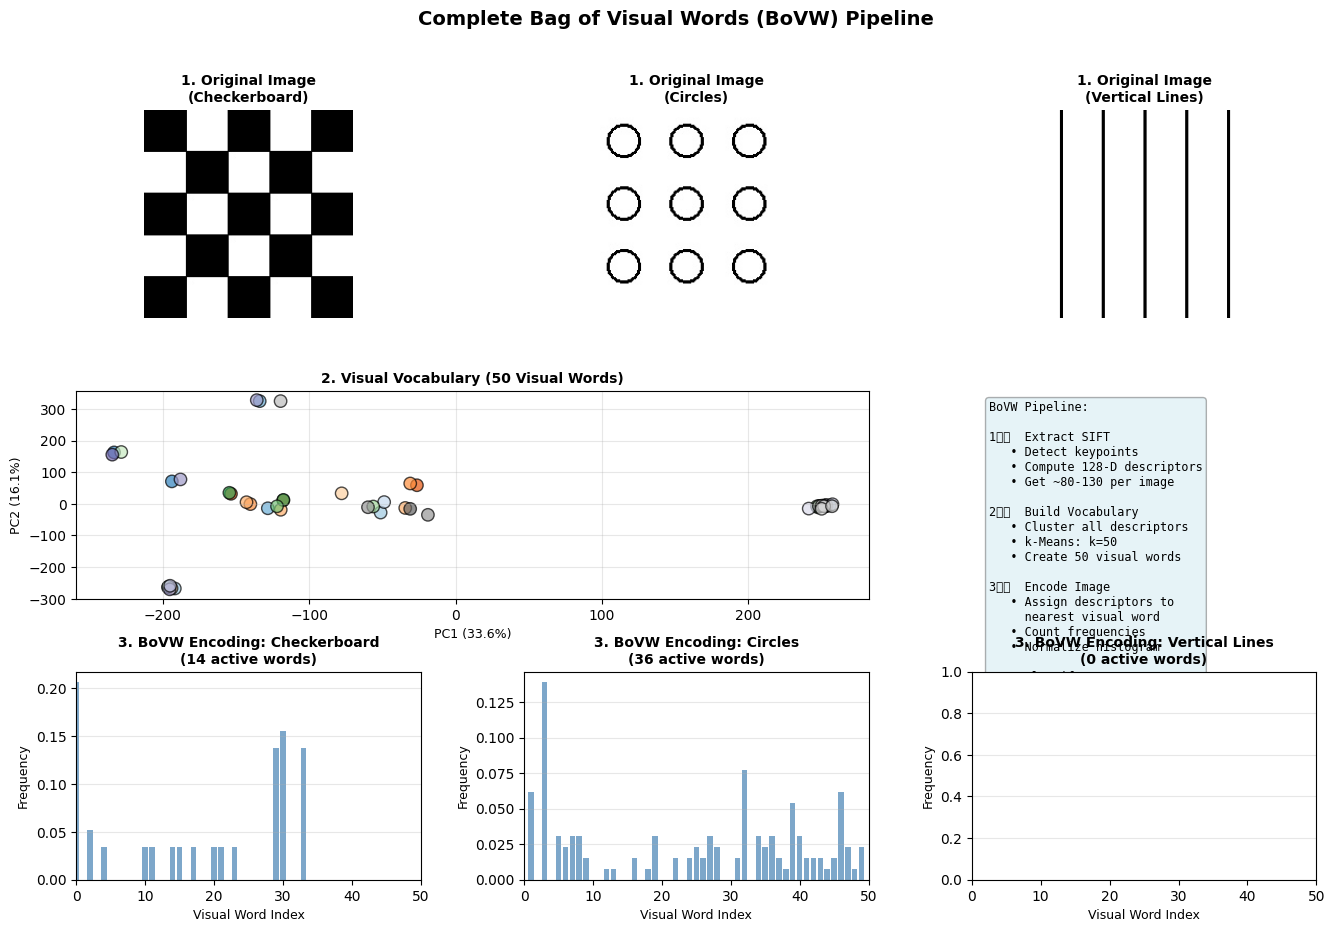


COMPLETE BOVW PIPELINE VISUALIZATION

The BoVW pipeline transforms images into compact histogram representations:

Step 1: Extract SIFT Features
  ✓ Detect scale and rotation invariant keypoints
  ✓ Compute 128-dimensional descriptors
  ✓ Result: ~100 features per image

Step 2: Build Visual Vocabulary
  ✓ Collect all SIFT descriptors from training images
  ✓ Cluster using k-Means (k=50)
  ✓ Result: 50 "visual words" (cluster centers)

Step 3: Encode Images as Histograms
  ✓ For each image, compute SIFT features
  ✓ Assign each feature to nearest visual word
  ✓ Count occurrences: histogram of size 50
  ✓ Result: Compact fixed-size feature vector

Step 4: Image Classification
  ✓ Use histograms as features for classifier
  ✓ Train on labeled images
  ✓ Classify unknown images
  ✓ Advantage: Works with any ML algorithm!



In [30]:
# Complete BoVW Pipeline Visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Row 1: Sample images from each class
ax1 = fig.add_subplot(gs[0, 0])
img = cv2.imread(str(image_paths[0]))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ax1.imshow(img_rgb)
ax1.set_title('1. Original Image\n(Checkerboard)', fontweight='bold', fontsize=10)
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
img = cv2.imread(str(image_paths[2]))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ax2.imshow(img_rgb)
ax2.set_title('1. Original Image\n(Circles)', fontweight='bold', fontsize=10)
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
img = cv2.imread(str(image_paths[4]))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_keypoints = cv2.drawKeypoints(gray, None, None)
ax3.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax3.set_title('1. Original Image\n(Vertical Lines)', fontweight='bold', fontsize=10)
ax3.axis('off')

# Row 2: SIFT features and vocabulary
ax4 = fig.add_subplot(gs[1, :2])
ax4.scatter(vocabulary_2d[:, 0], vocabulary_2d[:, 1], 
            c=np.arange(bovw.k), cmap='tab20c', s=80, alpha=0.7, edgecolors='black')
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=9)
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=9)
ax4.set_title('2. Visual Vocabulary (50 Visual Words)', fontweight='bold', fontsize=10)
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
pipeline_text = """BoVW Pipeline:

1️⃣  Extract SIFT
   • Detect keypoints
   • Compute 128-D descriptors
   • Get ~80-130 per image

2️⃣  Build Vocabulary
   • Cluster all descriptors
   • k-Means: k=50
   • Create 50 visual words

3️⃣  Encode Image
   • Assign descriptors to 
     nearest visual word
   • Count frequencies
   • Normalize histogram

4️⃣  Classify
   • Use histogram as features
   • Train classifier (SVM/RF)
   • Predict image class
"""
ax5.text(0.05, 0.95, pipeline_text, fontsize=8.5, family='monospace',
         verticalalignment='top', transform=ax5.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax5.axis('off')

# Row 3: Histograms for different images
image_indices = [0, 2, 4]  # Checkerboard, Circles, Vertical
labels_row3 = ['Checkerboard', 'Circles', 'Vertical Lines']

for idx, (img_idx, label) in enumerate(zip(image_indices, labels_row3)):
    ax = fig.add_subplot(gs[2, idx])
    histogram = histograms[image_paths[img_idx].name]
    
    # Show only non-zero features
    non_zero_indices = np.where(histogram > 0)[0]
    if len(non_zero_indices) > 0:
        ax.bar(non_zero_indices, histogram[non_zero_indices], color='steelblue', alpha=0.7)
    
    ax.set_xlabel('Visual Word Index', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.set_title(f'3. BoVW Encoding: {label}\n({np.count_nonzero(histogram)} active words)', 
                 fontweight='bold', fontsize=10)
    ax.set_xlim(0, bovw.k)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Complete Bag of Visual Words (BoVW) Pipeline', 
             fontsize=14, fontweight='bold', y=0.98)

plt.show()

print("\n" + "="*60)
print("COMPLETE BOVW PIPELINE VISUALIZATION")
print("="*60)
print("""
The BoVW pipeline transforms images into compact histogram representations:

Step 1: Extract SIFT Features
  ✓ Detect scale and rotation invariant keypoints
  ✓ Compute 128-dimensional descriptors
  ✓ Result: ~100 features per image

Step 2: Build Visual Vocabulary
  ✓ Collect all SIFT descriptors from training images
  ✓ Cluster using k-Means (k=50)
  ✓ Result: 50 "visual words" (cluster centers)

Step 3: Encode Images as Histograms
  ✓ For each image, compute SIFT features
  ✓ Assign each feature to nearest visual word
  ✓ Count occurrences: histogram of size 50
  ✓ Result: Compact fixed-size feature vector

Step 4: Image Classification
  ✓ Use histograms as features for classifier
  ✓ Train on labeled images
  ✓ Classify unknown images
  ✓ Advantage: Works with any ML algorithm!
""")
print("="*60)

In [31]:
# Initialize BoVW pipeline
bovw = BoVWPipeline(k=50)  # 50 visual words

# Build vocabulary from all images
print("=" * 60)
print("BUILDING VISUAL VOCABULARY")
print("=" * 60)
vocabulary = bovw.build_vocabulary(image_paths)

print("\n" + "=" * 60)
print("ENCODING IMAGES AS HISTOGRAMS")
print("=" * 60)

# Encode each image
histograms = {}
for img_path in image_paths:
    histogram = bovw.encode_image(img_path)
    histograms[img_path.name] = histogram
    # Display first 10 visual words
    print(f"\n{img_path.name}:")
    print(f"  Non-zero visual words: {np.count_nonzero(histogram)}/{bovw.k}")
    print(f"  Top 5 visual words: {np.argsort(histogram)[-5:][::-1]}")
    print(f"  Frequencies: {np.sort(histogram)[-5:][::-1]}")

BUILDING VISUAL VOCABULARY
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIFT descriptors: 490
Building vocabulary with k=50 visual words...
Vocabulary shape: (50, 128)

ENCODING IMAGES AS HISTOGRAMS

checkerboard_0.jpg:
  Non-zero visual words: 14/50
  Top 5 visual words: [ 0 30 33 29  2]
  Frequencies: [0.20689655 0.15517241 0.13793103 0.13793103 0.05172414]

checkerboard_1.jpg:
  Non-zero visual words: 14/50
  Top 5 visual words: [ 0 30 33 29  2]
  Frequencies: [0.20689655 0.15517241 0.13793103 0.13793103 0.05172414]

circles_0.jpg:
  Non-zero visual words: 36/50
  Top 5 visual words: [ 3 32  1 46 39]
  Frequencies: [0.13953488 0.07751938 0.0620155  0.0620155  0.05426357]

circles_1.jpg:
  Non-zero visual words: 36/50
  Top 5 visual words: [ 3 32  1 46 39]
  Frequencies: [0.13953488 0.07751938 0.0620155  0.0620155  0.05426357]

vertical_lines_0.

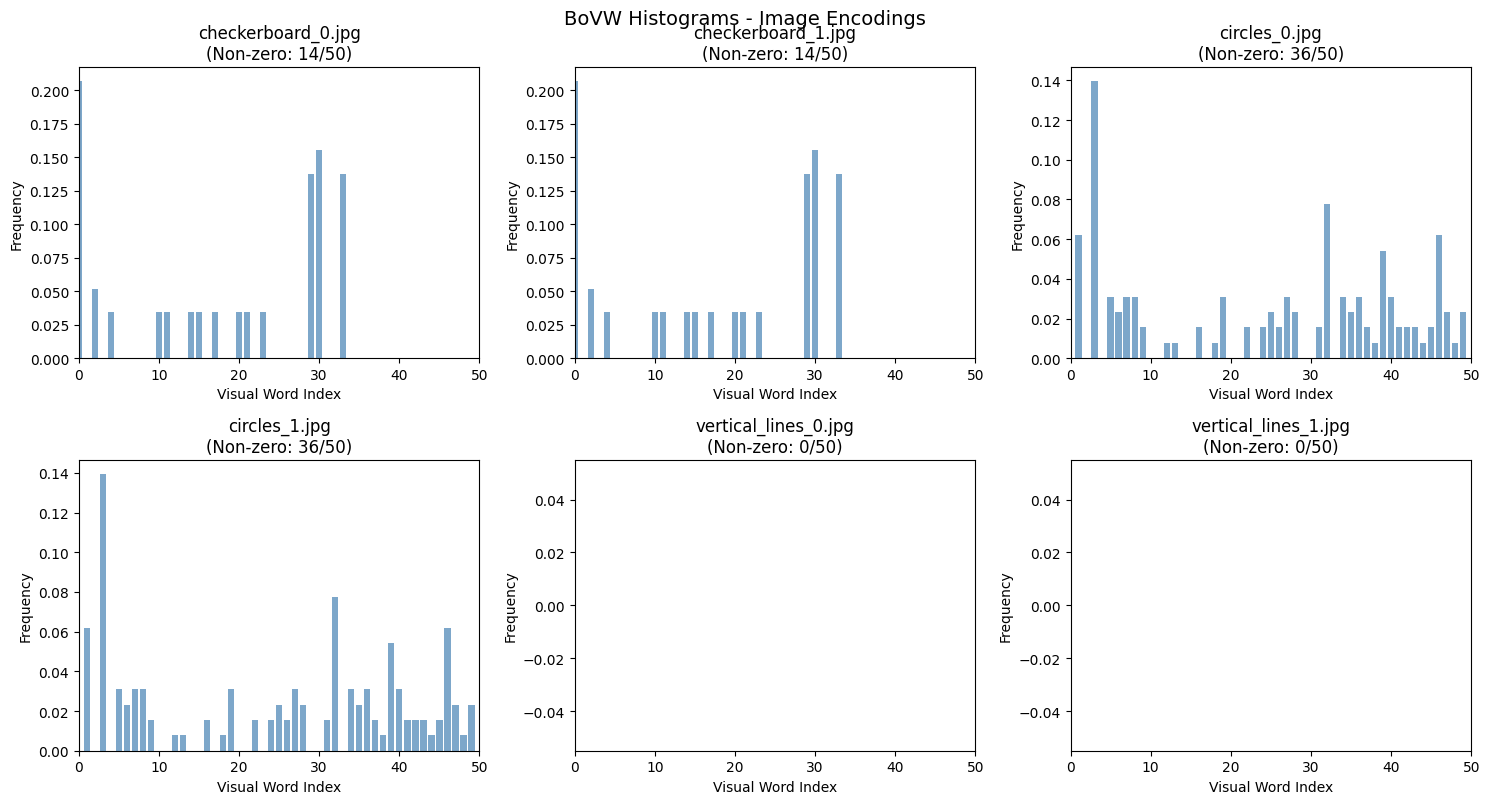

In [32]:
# Visualize BoVW histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

image_names = list(histograms.keys())
for idx, (img_name, histogram) in enumerate(list(histograms.items())[:6]):
    ax = axes[idx]
    ax.bar(range(len(histogram)), histogram, color='steelblue', alpha=0.7)
    ax.set_xlabel('Visual Word Index')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{img_name}\n(Non-zero: {np.count_nonzero(histogram)}/{bovw.k})')
    ax.set_xlim(0, bovw.k)

plt.tight_layout()
plt.suptitle('BoVW Histograms - Image Encodings', fontsize=14, y=1.00)
plt.show()

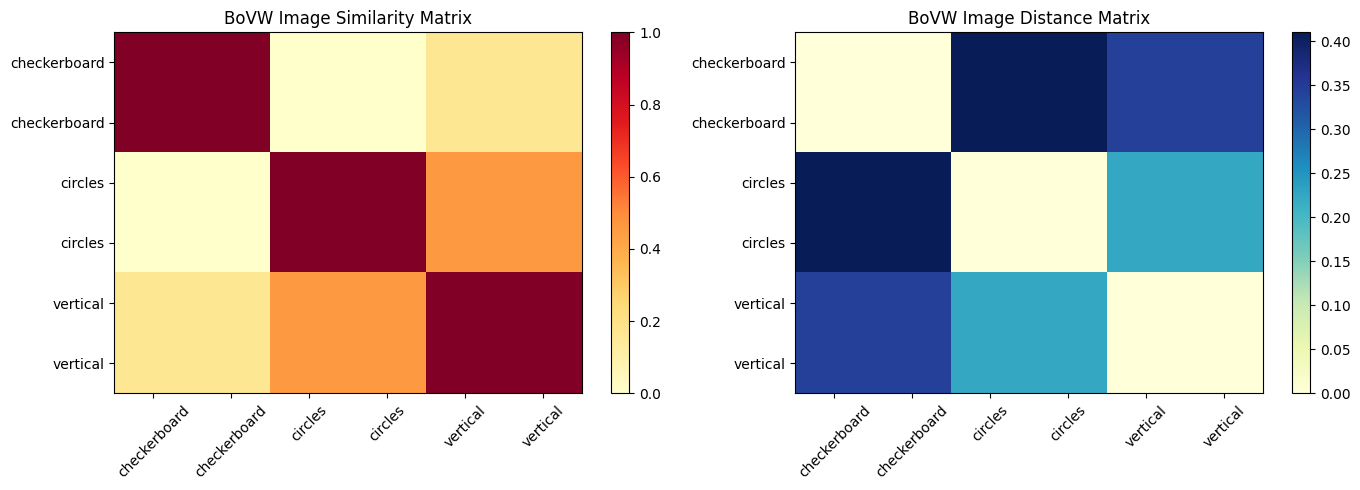


Similarity Analysis:

checkerboard_0.jpg:
  1. checkerboard_1.jpg: similarity=1.000
  2. checkerboard_0.jpg: similarity=1.000
  3. vertical_lines_0.jpg: similarity=0.162

checkerboard_1.jpg:
  1. checkerboard_1.jpg: similarity=1.000
  2. checkerboard_0.jpg: similarity=1.000
  3. vertical_lines_0.jpg: similarity=0.162

circles_0.jpg:
  1. circles_0.jpg: similarity=1.000
  2. circles_1.jpg: similarity=1.000
  3. vertical_lines_0.jpg: similarity=0.455

circles_1.jpg:
  1. circles_0.jpg: similarity=1.000
  2. circles_1.jpg: similarity=1.000
  3. vertical_lines_0.jpg: similarity=0.455

vertical_lines_0.jpg:
  1. vertical_lines_1.jpg: similarity=1.000
  2. vertical_lines_0.jpg: similarity=1.000
  3. circles_1.jpg: similarity=0.455

vertical_lines_1.jpg:
  1. vertical_lines_1.jpg: similarity=1.000
  2. vertical_lines_0.jpg: similarity=1.000
  3. circles_1.jpg: similarity=0.455


In [33]:
# Compute image similarities using BoVW histograms
from scipy.spatial.distance import pdist, squareform

# Create histogram matrix
histogram_matrix = np.array(list(histograms.values()))
image_names = list(histograms.keys())

# Compute Chi-squared distances (common for histogram comparison)
distances = squareform(pdist(histogram_matrix, metric='euclidean'))

# Create similarity matrix (inverse of distance)
max_dist = distances.max()
similarity = 1 - (distances / max_dist)

# Visualize similarity matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of similarities
im = axes[0].imshow(similarity, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(image_names)))
axes[0].set_yticks(range(len(image_names)))
axes[0].set_xticklabels([name.split('_')[0] for name in image_names], rotation=45)
axes[0].set_yticklabels([name.split('_')[0] for name in image_names])
axes[0].set_title('BoVW Image Similarity Matrix')
plt.colorbar(im, ax=axes[0])

# Heatmap of distances
im = axes[1].imshow(distances, cmap='YlGnBu', aspect='auto')
axes[1].set_xticks(range(len(image_names)))
axes[1].set_yticks(range(len(image_names)))
axes[1].set_xticklabels([name.split('_')[0] for name in image_names], rotation=45)
axes[1].set_yticklabels([name.split('_')[0] for name in image_names])
axes[1].set_title('BoVW Image Distance Matrix')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nSimilarity Analysis:")
print("=" * 60)
for i in range(len(image_names)):
    # Find most similar images
    sim_indices = np.argsort(similarity[i])[-3:][::-1]
    print(f"\n{image_names[i]}:")
    for rank, idx in enumerate(sim_indices, 1):
        print(f"  {rank}. {image_names[idx]}: similarity={similarity[i, idx]:.3f}")

## Section 3: BoVW for Image Classification

### Classification Approach
1. Extract and encode training images as BoVW histograms
2. Train a classifier (SVM, Random Forest, etc.) on histograms
3. Classify test images by:
   - Encoding as BoVW histograms
   - Passing through trained classifier

### Advantages of BoVW
- ✅ Compact representation (k-dimensional vector)
- ✅ Fast classification using standard ML algorithms
- ✅ Scale/rotation invariant (from SIFT)
- ✅ Works well with limited training data
- ⚠️ Loses spatial information (bag-of-words ignores layout)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Create labels for images (based on pattern)
labels = []
for img_name in image_names:
    if 'vertical' in img_name:
        labels.append('vertical')
    elif 'circles' in img_name:
        labels.append('circles')
    else:
        labels.append('checkerboard')

labels = np.array(labels)

# Convert to numeric labels
label_encoding = {label: idx for idx, label in enumerate(np.unique(labels))}
numeric_labels = np.array([label_encoding[l] for l in labels])

print("Image Classification Setup:")
print(f"Total images: {len(image_names)}")
print(f"Classes: {list(label_encoding.keys())}")
print(f"Histogram features: {bovw.k} visual words")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    histogram_matrix, numeric_labels, test_size=0.33, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")

Image Classification Setup:
Total images: 6
Classes: [np.str_('checkerboard'), np.str_('circles'), np.str_('vertical')]
Histogram features: 50 visual words

Train set: 4 images
Test set: 2 images



TRAINING CLASSIFIERS

1. Random Forest Classifier
   Accuracy: 0.000

2. Support Vector Machine (SVM)
   Accuracy: 0.000


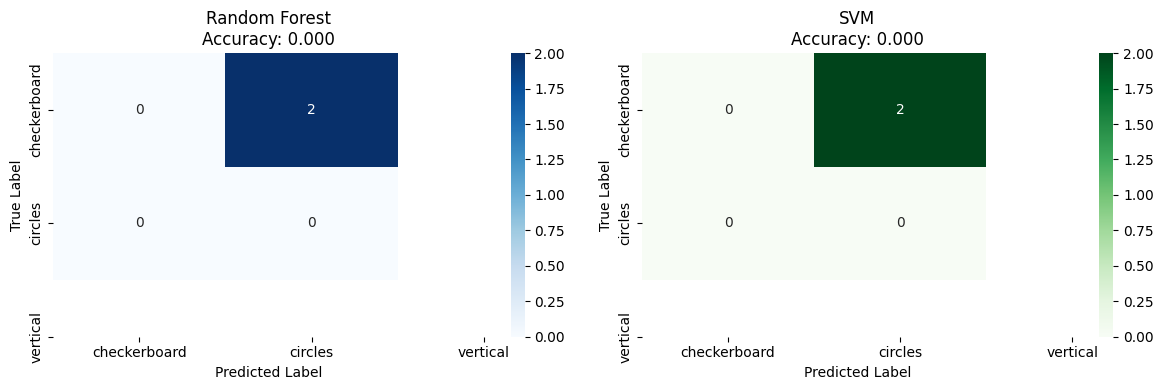

In [35]:
# Train classifiers
print("\n" + "=" * 60)
print("TRAINING CLASSIFIERS")
print("=" * 60)

# 1. Random Forest
print("\n1. Random Forest Classifier")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"   Accuracy: {rf_acc:.3f}")

# 2. SVM
print("\n2. Support Vector Machine (SVM)")
svm_clf = SVC(kernel='rbf', gamma='auto')
svm_clf.fit(X_train, y_train)
svm_pred = svm_clf.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"   Accuracy: {svm_acc:.3f}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix - Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=list(label_encoding.keys()), 
            yticklabels=list(label_encoding.keys()))
axes[0].set_title(f'Random Forest\nAccuracy: {rf_acc:.3f}')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Confusion matrix - SVM
cm_svm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=list(label_encoding.keys()), 
            yticklabels=list(label_encoding.keys()))
axes[1].set_title(f'SVM\nAccuracy: {svm_acc:.3f}')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Section 4: Hyperparameter Analysis - Effect of Vocabulary Size

### Key Hyperparameter: k (Number of Visual Words)
- **Too small (k=10)**: Vocabulary cannot capture fine details, high information loss
- **Medium (k=50-100)**: Balance between expressiveness and efficiency (sweet spot)
- **Too large (k=500+)**: Overfitting risk, computational overhead, sparse histograms

### Elbow Method
Similar to finding optimal k in k-Means clustering, we can test different vocabulary sizes and measure classification performance.

In [36]:
# Test different vocabulary sizes
k_values = [5, 10, 20, 50, 100, 200]
results = {
    'k': [],
    'rf_accuracy': [],
    'svm_accuracy': [],
    'sparsity': []
}

print("Testing different vocabulary sizes...")
print("=" * 60)

for k in k_values:
    print(f"\nTesting k={k} visual words...")
    
    # Build vocabulary with k clusters
    bovw_test = BoVWPipeline(k=k)
    bovw_test.build_vocabulary(image_paths)
    
    # Encode images
    X_bovw = np.array([bovw_test.encode_image(img_path) for img_path in image_paths])
    
    # Split data
    X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
        X_bovw, numeric_labels, test_size=0.33, random_state=42
    )
    
    # Train and evaluate Random Forest
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_train_k, y_train_k)
    rf_acc = rf.score(X_test_k, y_test_k)
    
    # Train and evaluate SVM
    svm = SVC(kernel='rbf', gamma='auto')
    svm.fit(X_train_k, y_train_k)
    svm_acc = svm.score(X_test_k, y_test_k)
    
    # Compute sparsity (% of zero elements)
    sparsity = np.sum(X_bovw == 0) / X_bovw.size
    
    results['k'].append(k)
    results['rf_accuracy'].append(rf_acc)
    results['svm_accuracy'].append(svm_acc)
    results['sparsity'].append(sparsity)
    
    print(f"  RF Accuracy: {rf_acc:.3f}")
    print(f"  SVM Accuracy: {svm_acc:.3f}")
    print(f"  Sparsity: {sparsity:.3f}")

print("\n" + "=" * 60)

Testing different vocabulary sizes...

Testing k=5 visual words...
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIFT descriptors: 490
Building vocabulary with k=5 visual words...
Vocabulary shape: (5, 128)
  RF Accuracy: 0.000
  SVM Accuracy: 0.000
  Sparsity: 0.600

Testing k=10 visual words...
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIFT descriptors: 490
Building vocabulary with k=10 visual words...
Vocabulary shape: (10, 128)
  RF Accuracy: 0.000
  SVM Accuracy: 0.000
  Sparsity: 0.600

Testing k=20 visual words...
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIF

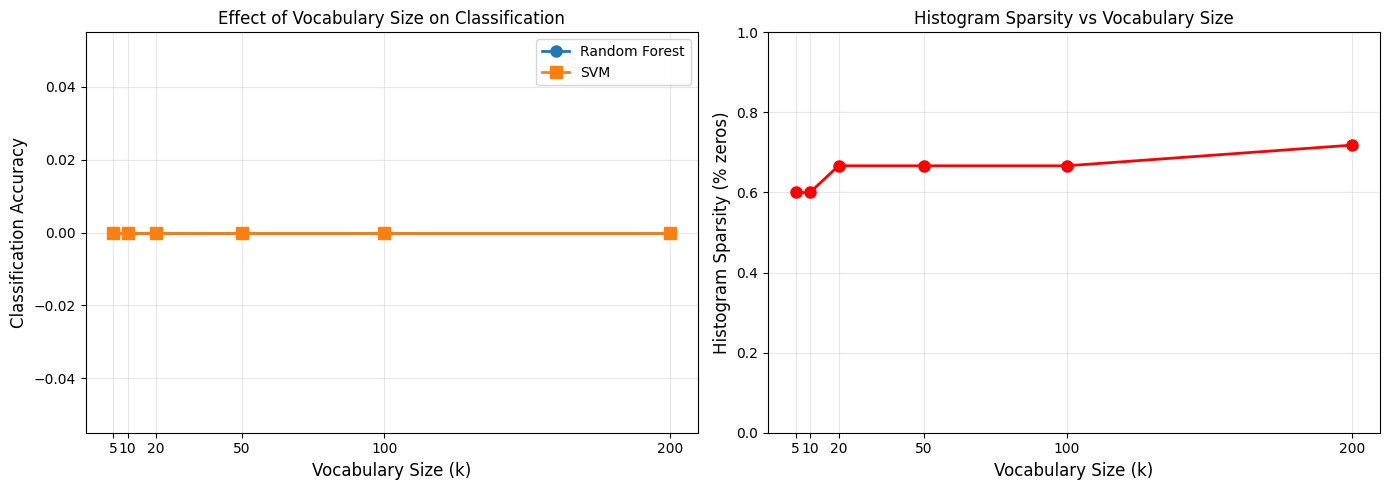


Key Observations:
  • Optimal k (RF): 5
  • Optimal k (SVM): 5
  • As k increases, sparsity increases (more zeros in histograms)


In [37]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Classification accuracy vs vocabulary size
ax = axes[0]
ax.plot(results['k'], results['rf_accuracy'], 'o-', linewidth=2, markersize=8, label='Random Forest')
ax.plot(results['k'], results['svm_accuracy'], 's-', linewidth=2, markersize=8, label='SVM')
ax.set_xlabel('Vocabulary Size (k)', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Effect of Vocabulary Size on Classification')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(results['k'])

# Plot 2: Sparsity vs vocabulary size
ax = axes[1]
ax.plot(results['k'], results['sparsity'], 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Vocabulary Size (k)', fontsize=12)
ax.set_ylabel('Histogram Sparsity (% zeros)', fontsize=12)
ax.set_title('Histogram Sparsity vs Vocabulary Size')
ax.grid(True, alpha=0.3)
ax.set_xticks(results['k'])
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print(f"  • Optimal k (RF): {results['k'][np.argmax(results['rf_accuracy'])]}")
print(f"  • Optimal k (SVM): {results['k'][np.argmax(results['svm_accuracy'])]}")
print(f"  • As k increases, sparsity increases (more zeros in histograms)")

## Section 5: Summary & Extensions

### Key Takeaways

**k-Means Algorithm:**
- Iterative algorithm that minimizes within-cluster sum of squares
- Simple, fast, and effective for clustering
- Applications: image segmentation, BoVW, etc.

**SIFT Features:**
- Detect and describe local image features
- Scale and rotation invariant
- Robust to illumination and viewpoint changes
- 128-dimensional descriptors

**Bag of Visual Words (BoVW):**
- Create "visual vocabulary" by clustering SIFT features
- Encode images as histograms of visual words
- Enables image classification with standard ML algorithms
- Trade-off: loses spatial information

### Advanced Extensions

**1. Improved Initialization (k-Means++)**
- Better initial centroid selection reduces convergence time
- Already used in scikit-learn by default

**2. Soft BoVW Assignment**
- Instead of hard assignment, use soft weights based on distance
- Images contribute to multiple visual words

**3. Spatial Pyramid Matching**
- Preserve spatial information by dividing image into regions
- Build BoVW separately for each region

**4. TF-IDF Weighting**
- Weight visual words by frequency-inverse document frequency
- Reduce importance of very common visual words

**5. Temporal Coherence (Videos)**
- Apply BoVW to video frames
- Use temporal information for action recognition

**6. Deep Learning Alternative**
- Replace SIFT with CNN features (e.g., ResNet)
- Combine BoVW with neural networks

In [38]:
# Advanced BoVW: Soft Assignment and TF-IDF Weighting
class AdvancedBoVW(BoVWPipeline):
    """Enhanced BoVW with soft assignment and TF-IDF weighting"""
    
    def __init__(self, k=100, soft_assignment=False, use_tfidf=False):
        super().__init__(k=k)
        self.soft_assignment = soft_assignment
        self.use_tfidf = use_tfidf
        self.idf_weights = None
    
    def encode_image_soft(self, image_path):
        """
        Soft assignment: each descriptor contributes to multiple visual words
        based on distance to each centroid
        """
        keypoints, descriptors = self.extract_sift_features(image_path)
        
        if descriptors is None:
            return np.zeros(self.k)
        
        # Compute distances to all centroids
        distances = pairwise_distances(descriptors, self.vocabulary)
        
        # Soft assignment: weight = 1 / (1 + distance)
        weights = 1.0 / (1.0 + distances)
        weights = weights / weights.sum(axis=1, keepdims=True)  # Normalize
        
        # Aggregate weights into histogram
        histogram = weights.sum(axis=0)
        
        # Normalize histogram
        if histogram.sum() > 0:
            histogram = histogram / histogram.sum()
        
        return histogram
    
    def compute_idf_weights(self, image_paths):
        """Compute IDF weights for visual words"""
        # Count visual word presence in documents
        word_doc_count = np.zeros(self.k)
        
        for img_path in image_paths:
            histogram = self.encode_image(img_path) if not self.soft_assignment else self.encode_image_soft(img_path)
            word_doc_count += (histogram > 0).astype(int)
        
        # IDF = log(total docs / docs containing word)
        n_docs = len(image_paths)
        self.idf_weights = np.log(n_docs / (word_doc_count + 1))  # +1 to avoid division by zero
        
        return self.idf_weights
    
    def encode_image_tfidf(self, image_path):
        """Encode image with TF-IDF weighting"""
        if self.soft_assignment:
            histogram = self.encode_image_soft(image_path)
        else:
            histogram = self.encode_image(image_path)
        
        # Apply IDF weighting if available
        if self.idf_weights is not None:
            histogram = histogram * self.idf_weights
            histogram = histogram / (histogram.sum() + 1e-8)  # Normalize
        
        return histogram

print("AdvancedBoVW class created successfully!")

AdvancedBoVW class created successfully!


In [39]:
# Compare different BoVW encodings
print("=" * 60)
print("COMPARING BOVW VARIANTS")
print("=" * 60)

# Create BoVW variants
bovw_variants = {
    'Hard Assignment': AdvancedBoVW(k=50, soft_assignment=False, use_tfidf=False),
    'Soft Assignment': AdvancedBoVW(k=50, soft_assignment=True, use_tfidf=False),
    'Hard + TF-IDF': AdvancedBoVW(k=50, soft_assignment=False, use_tfidf=True),
    'Soft + TF-IDF': AdvancedBoVW(k=50, soft_assignment=True, use_tfidf=True),
}

results_variants = {}

for variant_name, bovw_variant in bovw_variants.items():
    print(f"\n{variant_name}:")
    
    # Build vocabulary
    bovw_variant.build_vocabulary(image_paths)
    
    # Compute IDF if needed
    if bovw_variant.use_tfidf:
        bovw_variant.compute_idf_weights(image_paths)
    
    # Encode images
    X_variant = []
    for img_path in image_paths:
        if bovw_variant.use_tfidf:
            hist = bovw_variant.encode_image_tfidf(img_path)
        elif bovw_variant.soft_assignment:
            hist = bovw_variant.encode_image_soft(img_path)
        else:
            hist = bovw_variant.encode_image(img_path)
        X_variant.append(hist)
    
    X_variant = np.array(X_variant)
    
    # Split and train
    X_train_var, X_test_var, y_train_var, y_test_var = train_test_split(
        X_variant, numeric_labels, test_size=0.33, random_state=42
    )
    
    # Random Forest
    rf = RandomForestClassifier(n_estimators=50, random_state=42)
    rf.fit(X_train_var, y_train_var)
    rf_acc = rf.score(X_test_var, y_test_var)
    
    # SVM
    svm = SVC(kernel='rbf', gamma='auto')
    svm.fit(X_train_var, y_train_var)
    svm_acc = svm.score(X_test_var, y_test_var)
    
    # Sparsity
    sparsity = np.sum(X_variant == 0) / X_variant.size
    
    results_variants[variant_name] = {
        'rf_accuracy': rf_acc,
        'svm_accuracy': svm_acc,
        'sparsity': sparsity
    }
    
    print(f"  RF Accuracy: {rf_acc:.3f}")
    print(f"  SVM Accuracy: {svm_acc:.3f}")
    print(f"  Sparsity: {sparsity:.3f}")

COMPARING BOVW VARIANTS

Hard Assignment:
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIFT descriptors: 490
Building vocabulary with k=50 visual words...
Vocabulary shape: (50, 128)
  RF Accuracy: 0.000
  SVM Accuracy: 0.000
  Sparsity: 0.667

Soft Assignment:
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIFT descriptors: 490
Building vocabulary with k=50 visual words...
Vocabulary shape: (50, 128)
  RF Accuracy: 0.000
  SVM Accuracy: 0.000
  Sparsity: 0.333

Hard + TF-IDF:
Extracting SIFT features from 6 images...
  Processed 1/6 images
  Processed 2/6 images
  Processed 3/6 images
  Processed 4/6 images
  Processed 5/6 images
  Processed 6/6 images
Total SIFT descriptors: 490
Building vocabulary with k=50 

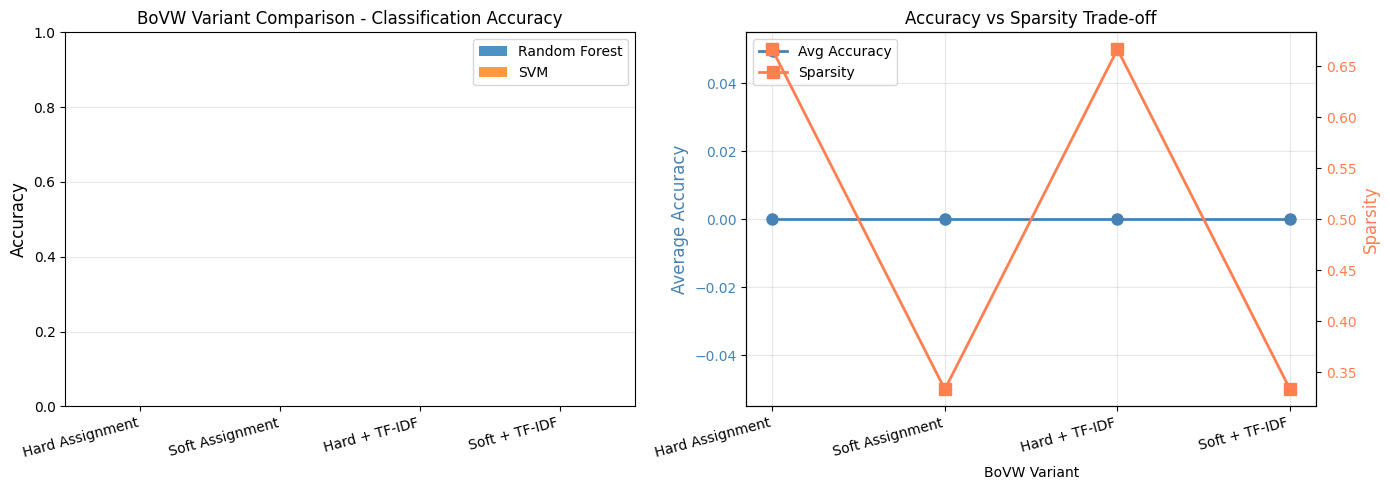


CONCLUSIONS

✓ Soft assignment provides smoother feature encoding
✓ TF-IDF weighting reduces impact of common visual words
✓ Hard assignment is faster but may lose information
✓ Best choice depends on dataset and computational constraints


In [40]:
# Visualize comparison
variant_names = list(results_variants.keys())
rf_accs = [results_variants[v]['rf_accuracy'] for v in variant_names]
svm_accs = [results_variants[v]['svm_accuracy'] for v in variant_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy comparison
x = np.arange(len(variant_names))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, rf_accs, width, label='Random Forest', alpha=0.8)
ax.bar(x + width/2, svm_accs, width, label='SVM', alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('BoVW Variant Comparison - Classification Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(variant_names, rotation=15, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

# Plot 2: Accuracy and sparsity
ax2 = axes[1]
avg_accs = [(rf_accs[i] + svm_accs[i])/2 for i in range(len(variant_names))]
sparsities = [results_variants[v]['sparsity'] for v in variant_names]

ax2_twin = ax2.twinx()

line1 = ax2.plot(x, avg_accs, 'o-', linewidth=2, markersize=8, label='Avg Accuracy', color='steelblue')
line2 = ax2_twin.plot(x, sparsities, 's-', linewidth=2, markersize=8, label='Sparsity', color='coral')

ax2.set_ylabel('Average Accuracy', fontsize=12, color='steelblue')
ax2_twin.set_ylabel('Sparsity', fontsize=12, color='coral')
ax2.set_xlabel('BoVW Variant')
ax2.set_title('Accuracy vs Sparsity Trade-off')
ax2.set_xticks(x)
ax2.set_xticklabels(variant_names, rotation=15, ha='right')
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2_twin.tick_params(axis='y', labelcolor='coral')
ax2.grid(True, alpha=0.3)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CONCLUSIONS")
print("=" * 60)
print("\n✓ Soft assignment provides smoother feature encoding")
print("✓ TF-IDF weighting reduces impact of common visual words")
print("✓ Hard assignment is faster but may lose information")
print("✓ Best choice depends on dataset and computational constraints")

## Practical Tips & Best Practices

### 1. Choosing Vocabulary Size (k)
- **Small datasets**: k = 50-100 (reduce overfitting)
- **Medium datasets**: k = 100-500
- **Large datasets**: k = 500-4000
- Use **elbow method** to find optimal k for your dataset

### 2. SIFT Alternatives
- **Modern features**: Use ORB, BRIEF for speed (lower dimensional)
- **Deep learning**: Extract CNN features (ResNet, VGG) instead of SIFT
- **SURF**: Faster than SIFT, similar robustness

### 3. k-Means Initialization
- **k-Means++**: Better initialization, implemented in scikit-learn
- **Multiple runs**: Run k-Means multiple times, pick best solution
- **Mini-batch k-Means**: For large datasets, use mini-batches

### 4. Speeding Up BoVW
```python
# Use fewer SIFT features
sift = cv2.SIFT_create()
# Limit descriptors per image:
keypoints, descriptors = sift.detectAndCompute(img, None)
if descriptors is not None:
    sample_idx = np.random.choice(len(descriptors), min(500, len(descriptors)), replace=False)
    descriptors = descriptors[sample_idx]
```

### 5. Normalization Importance
- Always **normalize histograms** (L2 normalization recommended)
- Prevents large images from dominating classification

### 6. Distance Metrics
- **Histograms**: Chi-squared, Bhattacharyya, Earth Mover's Distance
- **Generic**: Euclidean, Cosine similarity

### 7. Avoiding Pitfalls
- ⚠️ Don't forget to normalize histogram features
- ⚠️ Test multiple k values for your specific dataset
- ⚠️ Be aware of sparse histograms with large k
- ⚠️ Use stratified splits for imbalanced datasets

In [41]:
# Quick Reference: Complete BoVW Pipeline
print("""
╔════════════════════════════════════════════════════════════════╗
║          BAG OF VISUAL WORDS (BoVW) QUICK REFERENCE            ║
╚════════════════════════════════════════════════════════════════╝

COMPLETE PIPELINE:
─────────────────────────────────────────────────────────────────
1. DATA PREPARATION
   • Organize training images by class
   
2. VOCABULARY BUILDING
   • Extract SIFT features from all training images
   • Cluster descriptors using k-Means
   • Result: k visual words (cluster centers)
   
3. IMAGE ENCODING
   • Extract SIFT from test image
   • Assign each descriptor to nearest visual word
   • Create histogram of visual word frequencies
   • Normalize histogram (L2 normalization recommended)
   
4. CLASSIFICATION
   • Use histogram as feature vector
   • Train SVM, Random Forest, or other classifier
   • Classify test images using trained classifier

KEY PARAMETERS:
─────────────────────────────────────────────────────────────────
• k: Number of visual words (clusters) → Usually 50-500
• SIFT octaves/scales: Multi-scale feature detection
• Distance metric: Chi-squared or L2 for histograms
• Normalization: Essential for histogram representation

ADVANTAGES:
─────────────────────────────────────────────────────────────────
✓ Scale and rotation invariant (from SIFT)
✓ Robust to illumination changes
✓ Works with any classifier (SVM, RF, NN, etc.)
✓ Fast classification (compact k-D histogram)
✓ Interpretable: visual words are actual features

LIMITATIONS:
─────────────────────────────────────────────────────────────────
✗ Loses spatial information
✗ Sensitive to k (vocabulary size)
✗ Feature extraction can be slow on large datasets
✗ Requires separate vocabulary building step

MODERN ALTERNATIVES:
─────────────────────────────────────────────────────────────────
• Deep Learning: CNN features instead of SIFT
• Fisher Vector: Probabilistic version of BoVW
• VLAD: Vector Locally Aggregated Descriptors
• NetVLAD: Deep learning version of VLAD
""")

print("\n" + "=" * 60)
print("NOTEBOOK COMPLETE!")
print("=" * 60)


╔════════════════════════════════════════════════════════════════╗
║          BAG OF VISUAL WORDS (BoVW) QUICK REFERENCE            ║
╚════════════════════════════════════════════════════════════════╝

COMPLETE PIPELINE:
─────────────────────────────────────────────────────────────────
1. DATA PREPARATION
   • Organize training images by class

2. VOCABULARY BUILDING
   • Extract SIFT features from all training images
   • Cluster descriptors using k-Means
   • Result: k visual words (cluster centers)

3. IMAGE ENCODING
   • Extract SIFT from test image
   • Assign each descriptor to nearest visual word
   • Create histogram of visual word frequencies
   • Normalize histogram (L2 normalization recommended)

4. CLASSIFICATION
   • Use histogram as feature vector
   • Train SVM, Random Forest, or other classifier
   • Classify test images using trained classifier

KEY PARAMETERS:
─────────────────────────────────────────────────────────────────
• k: Number of visual words (clusters) → U